In [1]:
import pandas as pd
import numpy as np

pd.set_option('display.max_columns', None)
pd.reset_option('display.float_format')

In [2]:
trips = pd.read_csv("data/Transportation_Network_Providers_Trips_(2025)_20250416.csv", 
    dtype={'Pickup Census Tract': 'Int64', 'Dropoff Census Tract': 'Int64', 
           'Pickup Community Area': 'Int64', 'Dropoff Community Area': 'Int64'})

In [3]:
trips

,Trip ID,Trip Start Timestamp,Trip End Timestamp,Trip Seconds,Trip Miles,Percent Time Chicago,Percent Distance Chicago,Pickup Census Tract,Dropoff Census Tract,Pickup Community Area,Dropoff Community Area,Fare,Tip,Additional Charges,Trip Total,Shared Trip Authorized,Shared Trip Match,Trips Pooled,Pickup Centroid Latitude,Pickup Centroid Longitude,Pickup Centroid Location,Dropoff Centroid Latitude,Dropoff Centroid Longitude,Dropoff Centroid Location
0,f4c8e8579ca6e41ffbab25edde00a56cef75fbe9,04/16/2025 11:45:00 PM,04/17/2025 12:00:00 AM,732,5.5,68%,72%,<NA>,17031150200,<NA>,15,$7.5,$0,$3.55,$11.05,False,False,1,NaN,NaN,NaN,41.960676,-87.752409,POINT (-87.7524091367 41.9606756968)
1,f5045620992c5bb5cac200d5db51fbc9d1e980dc,04/16/2025 11:45:00 PM,04/17/2025 12:00:00 AM,396,1.0,99%,98%,17031081600,17031320100,8,32,$7.5,$0,$3.41,$10.91,False,False,1,41.892073,-87.628874,POINT (-87.6288741572 41.8920726347),41.884987,-87.620993,POINT (-87.6209929134 41.8849871918)
2,f5189089ccfbbde63cc147ad6c15a35b7d3acb89,04/16/2025 11:45:00 PM,04/16/2025 11:45:00 PM,737,2.9,100%,100%,17031060400,17031030500,6,77,$5,$3,$3.13,$11.13,False,False,1,41.950673,-87.666536,POINT (-87.6665362813 41.9506733576),41.987226,-87.664938,POINT (-87.6649377243 41.9872255578)
3,f53b28d0530f1e3657d0741e2cf98574a3683b75,04/16/2025 11:45:00 PM,04/17/2025 12:00:00 AM,310,1.5,100%,100%,<NA>,<NA>,41,39,$7.5,$0,$2.31,$9.81,False,False,1,41.794090,-87.592311,POINT (-87.592310855 41.794090253),41.808916,-87.596183,POINT (-87.5961833442 41.8089162826)
4,f55bc6fbaee328d0ee6108316cb12daf270099b9,04/16/2025 11:45:00 PM,04/17/2025 12:15:00 AM,"1,243",8.8,100%,100%,<NA>,<NA>,4,33,$12.5,$0,$3.33,$15.83,False,False,1,41.975171,-87.687516,POINT (-87.6875155152 41.9751709433),41.857184,-87.620335,POINT (-87.6203346241 41.8571838585)
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
231768,19e320f52f745a31fb9e936bb81054ff717a18f9,04/16/2025 12:00:00 AM,04/16/2025 12:15:00 AM,647,2.3,100%,100%,<NA>,<NA>,19,19,$5,$0,$1.45,$6.45,True,True,3,41.927261,-87.765502,POINT (-87.7655016086 41.9272609555),41.927261,-87.765502,POINT (-87.7655016086 41.9272609555)
231769,1a02329f69b0577a85ae428f8d1e8dbc47952ae1,04/16/2025 12:00:00 AM,04/16/2025 12:15:00 AM,"1,259",12.5,69%,76%,17031242300,<NA>,24,<NA>,$27.5,$0,$2.39,$29.89,False,False,1,41.899507,-87.679600,POINT (-87.6796002867 41.8995065476),NaN,NaN,NaN
231770,1a450fa5be8973044470459fb0996f917539193c,04/16/2025 12:00:00 AM,04/16/2025 12:15:00 AM,946,8.5,100%,100%,<NA>,<NA>,33,43,$15,$0,$3.63,$18.63,False,False,1,41.857184,-87.620335,POINT (-87.6203346241 41.8571838585),41.761578,-87.572782,POINT (-87.5727819867 41.7615779081)
231771,1acd6586d7fa041e6f6ba72c92ce334848422db5,04/16/2025 12:00:00 AM,04/16/2025 12:30:00 AM,"1,159",5.4,100%,100%,17031460400,17031710600,46,71,$15,$0,$1.23,$16.23,False,False,1,41.744491,-87.563693,POINT (-87.5636925942 41.7444906426),41.747660,-87.660943,POINT (-87.6609430664 41.7476603008)


# Privacy notes

These data are privacy protected.  If there are fewer than 4 trips in between a census tract pair in a 15 minute period, you get the community area coded instead of the Census tract.  This means that low-frequeny trips are disportionately dropped.  We will infer the location based on the reported distance.  We also note that trips without a community area are external and will be dropped.  

In [4]:
# drop if community area is missing--these are external to Chicago

trips_before = len(trips)
trips = trips[(trips['Pickup Community Area'] > 0) & (trips['Dropoff Community Area'] > 0) ].copy()
print("Before: " + str(trips_before) + " After: " + str(len(trips)))

Before: 231773 After: 182752


In [5]:
# read the equivalency between tracts and community areas
tracts = pd.read_csv('data/tract_2020_district_community.csv')
tracts

,STATEFP,COUNTYFP,TRACTCE,GEOID,NAME,NAMELSAD,MTFCC,FUNCSTAT,ALAND,AWATER,INTPTLAT,INTPTLON,RH_Zone,community,community_num
0,17,31,830600,17031830600,8306.00,Census Tract 8306,G5020,S,661394,0,42.001698,-87.673574,Other,ROGERS PARK,1.0
1,17,31,10702,17031010702,107.02,Census Tract 107.02,G5020,S,357548,0,42.009020,-87.672726,Other,ROGERS PARK,1.0
2,17,31,10503,17031010503,105.03,Census Tract 105.03,G5020,S,194213,0,42.000321,-87.663126,Other,ROGERS PARK,1.0
3,17,31,10502,17031010502,105.02,Census Tract 105.02,G5020,S,180386,0,42.004517,-87.663327,Other,ROGERS PARK,1.0
4,17,31,10701,17031010701,107.01,Census Tract 107.01,G5020,S,429690,0,42.009148,-87.678620,Other,ROGERS PARK,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3260,17,199,21002,17199021002,210.02,Census Tract 210.02,G5020,S,27269503,453271,37.753057,-88.990200,External,NaN,NaN
3261,17,199,20801,17199020801,208.01,Census Tract 208.01,G5020,S,153192395,1647960,37.813387,-88.812192,External,NaN,NaN
3262,17,199,21003,17199021003,210.03,Census Tract 210.03,G5020,S,4058483,83663,37.743576,-88.949876,External,NaN,NaN
3263,17,91,11700,17091011700,117.00,Census Tract 117,G5020,S,2373268,102060,41.129465,-87.873580,External,NaN,NaN


In [6]:
# free flow driving times
fftimes = pd.read_parquet('data/times-0.0.1-car-2020-tract-17-0.parquet')
fftimes['origin_id'] = fftimes['origin_id'].astype('Int64')
fftimes['destination_id'] = fftimes['destination_id'].astype('Int64')
fftimes

,centroid_type,origin_id,destination_id,duration_sec,chunk_id
0,weighted,17001000100,1033020100,34824.5,
1,weighted,17001000100,1033020200,34681.7,
2,weighted,17001000100,1033020300,34643.5,
3,weighted,17001000100,1033020400,34703.4,
4,weighted,17001000100,1033020500,34389.3,
...,...,...,...,...,...
45465120,weighted,17203030700,55141011300,19272.2,
45465121,weighted,17203030700,55141011400,19301.9,
45465122,weighted,17203030700,55141011500,19199.8,
45465123,weighted,17203030700,55141011600,18712.8,


In [7]:
# walking times
# Note that based on the OSRM profile, these are dominantly at 5 km/hr
# See: https://github.com/Project-OSRM/osrm-backend/blob/master/profiles/foot.lua 

walk_times = pd.read_parquet('data/times-0.0.1-foot-2024-tract-17-0.parquet')
walk_times['origin_id'] = walk_times['origin_id'].astype('Int64')
walk_times['destination_id'] = walk_times['destination_id'].astype('Int64')
walk_times

,centroid_type,origin_id,destination_id,duration_sec,chunk_id
0,weighted,17001000100,1033020100,584852.7,0000-3265_00000-13925
1,weighted,17001000100,1033020200,586165.3,0000-3265_00000-13925
2,weighted,17001000100,1033020300,586540.4,0000-3265_00000-13925
3,weighted,17001000100,1033020400,588708.3,0000-3265_00000-13925
4,weighted,17001000100,1033020500,589655.9,0000-3265_00000-13925
...,...,...,...,...,...
45438140,weighted,17203030700,55141011300,323140.8,0000-3265_00000-13925
45438141,weighted,17203030700,55141011400,323452.3,0000-3265_00000-13925
45438142,weighted,17203030700,55141011500,320614.2,0000-3265_00000-13925
45438143,weighted,17203030700,55141011600,317579.7,0000-3265_00000-13925


In [8]:
# calculate walk distance, assuming 5 km/hr speeds
walk_times['walk_dist_miles'] = (walk_times['duration_sec'] / 3600) * (5 / 1.609)

# Estimate congestion factors and fare. 



In [9]:
# ---- Setup for tract inference --------------------------------------------
# Map each Chicago community area number -> array of its Census tract GEOIDs.
chi_tracts = tracts[tracts['community_num'].notna()].copy()
chi_tracts['community_num'] = chi_tracts['community_num'].astype(int)

ca_to_tracts = (chi_tracts.groupby('community_num')['GEOID']
                .apply(lambda s: s.to_numpy())
                .to_dict())
chicago_geoids = set(chi_tracts['GEOID'])

# Walk-distance lookup restricted to Chicago tract pairs.
walk_chi = walk_times[
    walk_times['origin_id'].isin(chicago_geoids)
    & walk_times['destination_id'].isin(chicago_geoids)
][['origin_id', 'destination_id', 'walk_dist_miles']].drop_duplicates(
    subset=['origin_id', 'destination_id'])

dist_lookup = walk_chi.set_index(['origin_id', 'destination_id'])['walk_dist_miles']

print(f"{len(ca_to_tracts)} community areas, "
      f"{len(chicago_geoids)} Chicago tracts, "
      f"{len(dist_lookup):,} walk-distance pairs")

77 community areas, 792 Chicago tracts, 625,682 walk-distance pairs


In [10]:
# ---- Congestion factors by time period ------------------------------------
# Recompute the congestion factor (congested car time / free-flow car time)
# directly from the observed TNP trips, using the SAME time periods as
# Make Estimation File.ipynb. Based only on trips where BOTH Census tracts are
# observed (both ends are already filtered to Chicago).

# 1. Time period from the trip start hour (same bins as the estimation file).
trips['depart_hour'] = pd.to_datetime(
    trips['Trip Start Timestamp'], format='%m/%d/%Y %I:%M:%S %p').dt.hour
trips['time_period'] = pd.cut(
    trips['depart_hour'], bins=[-1, 5, 8, 15, 18, 21, 23],
    labels=['night', 'am_peak', 'midday', 'pm_peak', 'evening', 'night'],
    ordered=False)
trips['time_period'] = trips['time_period'].cat.reorder_categories(
    ['night', 'am_peak', 'midday', 'pm_peak', 'evening'], ordered=True)

# 2. Trip Seconds is read from the CSV as text ("1,243") -> make it numeric.
trips['Trip Seconds'] = pd.to_numeric(
    trips['Trip Seconds'].astype(str).str.replace(',', '', regex=False),
    errors='coerce')

# 3. Free-flow car time (seconds) for Chicago O-D tract pairs.
ff_sec = fftimes[
    fftimes['origin_id'].isin(chicago_geoids)
    & fftimes['destination_id'].isin(chicago_geoids)
][['origin_id', 'destination_id', 'duration_sec']].rename(
    columns={'duration_sec': 'ff_sec'})

# 4. Observed-tract trips only; attach free-flow time by O-D tract.
obs = trips[trips['Pickup Census Tract'].notna()
            & trips['Dropoff Census Tract'].notna()].copy()
obs = obs.merge(ff_sec,
                left_on=['Pickup Census Tract', 'Dropoff Census Tract'],
                right_on=['origin_id', 'destination_id'], how='left')

# 5. Drop intra-zonal / zero free-flow pairs (centroid distance ~0 -> bad ratio).
obs = obs[(obs['ff_sec'] > 0)
          & (obs['Pickup Census Tract'] != obs['Dropoff Census Tract'])
          & obs['Trip Seconds'].notna()].copy()

# 6. Congestion factor per time period.
#    Headline factor = ratio of total observed seconds to total free-flow
#    seconds (robust to small denominators); mean/median per-trip ratios shown
#    for reference.
obs['ratio'] = obs['Trip Seconds'] / obs['ff_sec']
g = obs.groupby('time_period', observed=True)

factors = pd.DataFrame({
    'n_trips':      g.size(),
    'sum_trip_sec': g['Trip Seconds'].sum(),
    'sum_ff_sec':   g['ff_sec'].sum(),
    'mean_ratio':   g['ratio'].mean(),
    'median_ratio': g['ratio'].median(),
})
factors['congestion_factor'] = factors['sum_trip_sec'] / factors['sum_ff_sec']

# Published values currently used in the model (Mucci & Erhardt 2023, Table 2).
published = {'night': 0.8489, 'am_peak': 1.1825, 'midday': 1.1331,
            'pm_peak': 1.2906, 'evening': 0.9292}
factors['published'] = factors.index.map(published)

factors = factors[['n_trips', 'congestion_factor', 'mean_ratio',
                   'median_ratio', 'published']]
factors['n_trips'] = factors['n_trips'].astype(int)
print(factors.round(4).to_string())

             n_trips  congestion_factor  mean_ratio  median_ratio published
time_period                                                                
night          10891             1.1908      1.6254        1.5328    0.8489
am_peak        13854             1.7503      2.1160        1.9933    1.1825
midday         38237             1.6550      2.0643        1.9351    1.1331
pm_peak        22508             2.2462      2.6542        2.4438    1.2906
evening        21319             1.5996      1.9867        1.8750    0.9292


In [11]:
# ---- Recomputed congestion factors, ready to paste into the estimation file -
period_order = ['night', 'am_peak', 'midday', 'pm_peak', 'evening']
congestion_factors = {p: round(float(factors.loc[p, 'congestion_factor']), 4)
                      for p in period_order}

print("congestion_factors = {")
for p in period_order:
    print(f"    '{p}':{'':<{9 - len(p)}}{congestion_factors[p]},")
print("}")

congestion_factors = {
    'night':    1.1908,
    'am_peak':  1.7503,
    'midday':   1.655,
    'pm_peak':  2.2462,
    'evening':  1.5996,
}


In [12]:
# create table with congested times

car_times = fftimes.copy()
car_times['fftime'] = car_times['duration_sec'] / 60
for period in congestion_factors.keys(): 
    car_times['time_' + period] = car_times['fftime'] * congestion_factors[period]
car_times.head(10)

,centroid_type,origin_id,destination_id,duration_sec,chunk_id,fftime,time_night,time_am_peak,time_midday,time_pm_peak,time_evening
0,weighted,17001000100,1033020100,34824.5,,580.408333,691.150243,1015.888706,960.575792,1303.713198,928.421170
1,weighted,17001000100,1033020200,34681.7,,578.028333,688.316139,1011.722992,956.636892,1298.367242,924.614122
2,weighted,17001000100,1033020300,34643.5,,577.391667,687.557997,1010.608634,955.583208,1296.937162,923.595710
3,weighted,17001000100,1033020400,34703.4,,578.390000,688.746812,1012.356017,957.235450,1299.179618,925.192644
4,weighted,17001000100,1033020500,34389.3,,573.155000,682.512974,1003.193197,948.571525,1287.420761,916.818738
5,weighted,17001000100,1033020600,34536.8,,575.613333,685.440357,1007.496017,952.640067,1292.942669,920.751088
6,weighted,17001000100,1033020703,34882.9,,581.381667,692.309289,1017.592331,962.186658,1305.899500,929.978114
7,weighted,17001000100,1033020704,34670.2,,577.836667,688.087903,1011.387518,956.319683,1297.936721,924.307532
8,weighted,17001000100,1033020705,35398.6,,589.976667,702.544215,1032.636160,976.411383,1325.205589,943.726676
9,weighted,17001000100,1033020706,34697.7,,578.295000,688.633686,1012.189738,957.078225,1298.966229,925.040682


In [13]:
# ---- Linear regression for TNP fare ---------------------------------------
# Fare ~ const + Trip Seconds + Trip Miles, estimated separately for shared
# vs non-shared trips (Shared Trip Authorized).
import statsmodels.api as sm


def to_num(s):
    return pd.to_numeric(s.astype(str).str.replace('[$,]', '', regex=True),
                         errors='coerce')

fare = pd.DataFrame({
    'Fare':         to_num(trips['Fare']),
    'Trip Seconds': to_num(trips['Trip Seconds']),
    'Trip Miles':   to_num(trips['Trip Miles']),
    'Shared Trip Authorized': trips['Shared Trip Authorized'],
}).dropna(subset=['Fare', 'Trip Seconds', 'Trip Miles'])

fare_models = {}
for authorized in [False, True]:
    sub = fare[fare['Shared Trip Authorized'] == authorized]
    X = sm.add_constant(sub[['Trip Seconds', 'Trip Miles']])
    model = sm.OLS(sub['Fare'], X).fit()
    fare_models[authorized] = model
    print(f"\n===== Shared Trip Authorized = {authorized}  (n = {len(sub):,}) =====")
    print(model.summary())


===== Shared Trip Authorized = False  (n = 175,447) =====
                            OLS Regression Results                            
Dep. Variable:                   Fare   R-squared:                       0.721
Model:                            OLS   Adj. R-squared:                  0.721
Method:                 Least Squares   F-statistic:                 2.269e+05
Date:                Thu, 18 Jun 2026   Prob (F-statistic):               0.00
Time:                        13:14:11   Log-Likelihood:            -5.6501e+05
No. Observations:              175447   AIC:                         1.130e+06
Df Residuals:                  175444   BIC:                         1.130e+06
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                   coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------

# Infer Census tracts for privacy-suppressed trips

Where a trip reports only the community area (the tract was suppressed for privacy), infer the tract two ways and store each in its own columns so they can be compared. Observed tracts are always carried through unchanged.

### Approach 1: random tract within the community area

Where the tract is observed, keep it. Where only the community area is reported, draw a tract uniformly at random from the tracts that fall in that community area (per the `tracts` equivalency).

In [14]:
# ---- Approach 1: random tract within the community area --------------------
rng = np.random.default_rng(42)  # seed for reproducibility

def infer_random(df, tract_col, ca_col, out_col):
    df[out_col] = df[tract_col]                       # keep observed tracts
    missing = df.index[df[out_col].isna()]
    ca = df.loc[missing, ca_col]
    for area, sub in ca.groupby(ca):                  # one community area at a time
        cands = ca_to_tracts.get(int(area))
        if cands is None or len(cands) == 0:
            continue
        df.loc[sub.index, out_col] = rng.choice(cands, size=len(sub))

infer_random(trips, 'Pickup Census Tract',  'Pickup Community Area',
             'Inferred Pickup Census Tract (random)')
infer_random(trips, 'Dropoff Census Tract', 'Dropoff Community Area',
             'Inferred Dropoff Census Tract (random)')

trips[['Pickup Census Tract',  'Pickup Community Area',
       'Inferred Pickup Census Tract (random)',
       'Dropoff Census Tract', 'Dropoff Community Area',
       'Inferred Dropoff Census Tract (random)']].head(10)

,Pickup Census Tract,Pickup Community Area,Inferred Pickup Census Tract (random),Dropoff Census Tract,Dropoff Community Area,Inferred Dropoff Census Tract (random)
1,17031081600,8,17031081600,17031320100,32,17031320100
2,17031060400,6,17031060400,17031030500,77,17031030500
3,<NA>,41,17031836300,<NA>,39,17031390400
4,<NA>,4,17031040700,<NA>,33,17031330102
5,<NA>,31,17031310900,<NA>,28,17031280900
6,17031839100,32,17031839100,17031062000,6,17031062000
7,<NA>,6,17031062000,<NA>,7,17031071800
8,<NA>,28,17031281900,<NA>,28,17031283800
9,17031980000,76,17031980000,17031081300,8,17031081300
10,17031301600,30,17031301600,17031310400,31,17031310400


### Approach 2: distance-matched tract pair

For each suppressed trip, enumerate every candidate pickup tract (from the pickup community area) crossed with every candidate dropoff tract (from the dropoff community area), and keep the pair whose `walk_dist_miles` is closest to the recorded `Trip Miles`. Observed tracts are held fixed, so only the suppressed end(s) vary.

In [15]:
# ---- Approach 2: distance-matched tract pair ------------------------------
# For each trip with a missing tract, enumerate candidate (pickup, dropoff)
# tract pairs and keep the pair whose walk_dist_miles is closest to Trip Miles.
# NOTE: walk_dist_miles is network *walking* distance, not identical to the
# recorded *driving* Trip Miles -- it is used here as the best available proxy.

# Start the output columns from the observed values (kept where not suppressed).
trips['Inferred Pickup Census Tract (distance)']  = trips['Pickup Census Tract']
trips['Inferred Dropoff Census Tract (distance)'] = trips['Dropoff Census Tract']

def candidate_tracts(tract, area):
    # observed tract -> only itself; suppressed -> every tract in its community area
    if pd.notna(tract):
        return np.array([tract], dtype='int64')
    return ca_to_tracts.get(int(area), np.empty(0, dtype='int64'))

dist_df = dist_lookup.reset_index()  # origin_id, destination_id, walk_dist_miles

def match_chunk(chunk):
    cand = pd.DataFrame({
        'trip_idx': chunk.index,
        'p_list': [candidate_tracts(t, a) for t, a
                   in zip(chunk['Pickup Census Tract'], chunk['Pickup Community Area'])],
        'd_list': [candidate_tracts(t, a) for t, a
                   in zip(chunk['Dropoff Census Tract'], chunk['Dropoff Community Area'])],
    })

    p = cand[['trip_idx', 'p_list']].explode('p_list').rename(columns={'p_list': 'p'})
    d = cand[['trip_idx', 'd_list']].explode('d_list').rename(columns={'d_list': 'd'})
    pairs = p.merge(d, on='trip_idx')                 # cross product within each trip
    pairs['p'] = pairs['p'].astype('int64')
    pairs['d'] = pairs['d'].astype('int64')

    # attach walk distance; same-tract pairs may be absent from the matrix -> 0 miles
    pairs = pairs.merge(dist_df, left_on=['p', 'd'],
                        right_on=['origin_id', 'destination_id'], how='left')
    pairs.loc[(pairs['p'] == pairs['d']) & pairs['walk_dist_miles'].isna(),
              'walk_dist_miles'] = 0.0

    # attach the trip's target distance and pick the closest pair per trip
    pairs = pairs.merge(chunk[['Trip Miles']].rename_axis('trip_idx').reset_index(),
                        on='trip_idx')
    pairs['diff'] = (pairs['walk_dist_miles'] - pairs['Trip Miles']).abs()
    pairs = pairs.dropna(subset=['diff'])
    best = pairs.loc[pairs.groupby('trip_idx')['diff'].idxmin()]
    return best[['trip_idx', 'p', 'd']]

# Only trips with at least one suppressed tract need inference.
need = trips[trips['Pickup Census Tract'].isna()
             | trips['Dropoff Census Tract'].isna()]

# Process in chunks to keep the candidate-pair cross product memory-bounded.
CHUNK = 20000
best = pd.concat([match_chunk(need.iloc[i:i + CHUNK])
                  for i in range(0, len(need), CHUNK)], ignore_index=True)

trips.loc[best['trip_idx'], 'Inferred Pickup Census Tract (distance)']  = best['p'].values
trips.loc[best['trip_idx'], 'Inferred Dropoff Census Tract (distance)'] = best['d'].values

trips[['Trip Miles', 'Pickup Census Tract',  'Dropoff Census Tract',
       'Pickup Community Area',  'Inferred Pickup Census Tract (distance)',
       'Dropoff Community Area', 'Inferred Dropoff Census Tract (distance)']].head(10)

,Trip Miles,Pickup Census Tract,Dropoff Census Tract,Pickup Community Area,Inferred Pickup Census Tract (distance),Dropoff Community Area,Inferred Dropoff Census Tract (distance)
1,1.0,17031081600,17031320100,8,17031081600,32,17031320100
2,2.9,17031060400,17031030500,6,17031060400,77,17031030500
3,1.5,<NA>,<NA>,41,17031410800,39,17031390200
4,8.8,<NA>,<NA>,4,17031040401,33,17031330102
5,1.5,<NA>,<NA>,31,17031310800,28,17031832900
6,6.2,17031839100,17031062000,32,17031839100,6,17031062000
7,1.7,<NA>,<NA>,6,17031062200,7,17031832500
8,1.8,<NA>,<NA>,28,17031833100,28,17031282800
9,18.5,17031980000,17031081300,76,17031980000,8,17031081300
10,4.0,17031301600,17031310400,30,17031301600,31,17031310400


### Approach 3: congested-car-time-matched tract pair

Same idea as Approach 2, but instead of matching walking distance to `Trip Miles`, match the **congested car time** for each candidate tract pair (from `car_times`, in minutes) to the recorded travel time (`Trip Seconds / 60`). The congested time is period-specific, so each trip is matched using the `time_<period>` column for its own `time_period`.

In [16]:
# ---- Approach 3: congested-car-time-matched tract pair --------------------
# Like Approach 2, but match the period-specific congested car time (minutes,
# from car_times) for each candidate tract pair against the trip's observed
# travel time (Trip Seconds / 60). The relevant congested time depends on the
# trip's time_period, so we use the matching time_<period> column.

# Long, Chicago-only congested-time lookup: one row per (origin, destination, period).
time_cols = [c for c in car_times.columns if c.startswith('time_')]
car_chi = car_times[
    car_times['origin_id'].isin(chicago_geoids)
    & car_times['destination_id'].isin(chicago_geoids)
]
car_long = car_chi.melt(
    id_vars=['origin_id', 'destination_id'], value_vars=time_cols,
    var_name='time_period', value_name='car_min')
car_long['time_period'] = car_long['time_period'].str.replace('time_', '', regex=False)

# Start the output columns from the observed values (kept where not suppressed).
trips['Inferred Pickup Census Tract (time)']  = trips['Pickup Census Tract']
trips['Inferred Dropoff Census Tract (time)'] = trips['Dropoff Census Tract']

def match_chunk_time(chunk):
    cand = pd.DataFrame({
        'trip_idx':    chunk.index,
        'time_period': chunk['time_period'].astype(str).values,
        'target_min':  (chunk['Trip Seconds'] / 60).values,   # observed minutes
        'p_list': [candidate_tracts(t, a) for t, a
                   in zip(chunk['Pickup Census Tract'], chunk['Pickup Community Area'])],
        'd_list': [candidate_tracts(t, a) for t, a
                   in zip(chunk['Dropoff Census Tract'], chunk['Dropoff Community Area'])],
    })

    p = cand[['trip_idx', 'p_list']].explode('p_list').rename(columns={'p_list': 'p'})
    d = cand[['trip_idx', 'd_list']].explode('d_list').rename(columns={'d_list': 'd'})
    pairs = p.merge(d, on='trip_idx')                 # cross product within each trip
    pairs['p'] = pairs['p'].astype('int64')
    pairs['d'] = pairs['d'].astype('int64')

    # attach this trip's period + target time, then the period's congested car time
    pairs = pairs.merge(cand[['trip_idx', 'time_period', 'target_min']], on='trip_idx')
    pairs = pairs.merge(
        car_long, left_on=['p', 'd', 'time_period'],
        right_on=['origin_id', 'destination_id', 'time_period'], how='left')

    pairs['diff'] = (pairs['car_min'] - pairs['target_min']).abs()
    pairs = pairs.dropna(subset=['diff'])
    best = pairs.loc[pairs.groupby('trip_idx')['diff'].idxmin()]
    return best[['trip_idx', 'p', 'd']]

# Only trips with at least one suppressed tract need inference.
need = trips[trips['Pickup Census Tract'].isna()
             | trips['Dropoff Census Tract'].isna()]

# Process in chunks to keep the candidate-pair cross product memory-bounded.
CHUNK = 20000
best = pd.concat([match_chunk_time(need.iloc[i:i + CHUNK])
                  for i in range(0, len(need), CHUNK)], ignore_index=True)

trips.loc[best['trip_idx'], 'Inferred Pickup Census Tract (time)']  = best['p'].values
trips.loc[best['trip_idx'], 'Inferred Dropoff Census Tract (time)'] = best['d'].values

trips[['Trip Seconds', 'time_period',
       'Pickup Community Area',  'Inferred Pickup Census Tract (time)',
       'Dropoff Community Area', 'Inferred Dropoff Census Tract (time)']].head(10)

,Trip Seconds,time_period,Pickup Community Area,Inferred Pickup Census Tract (time),Dropoff Community Area,Inferred Dropoff Census Tract (time)
1,396,night,8,17031081600,32,17031320100
2,737,night,6,17031060400,77,17031030500
3,310,night,41,17031411100,39,17031390500
4,1243,night,4,17031040100,33,17031330200
5,314,night,31,17031843200,28,17031832900
6,1059,night,32,17031839100,6,17031062000
7,457,night,6,17031060300,7,17031832600
8,523,night,28,17031282700,28,17031281900
9,1335,night,76,17031980000,8,17031081300
10,737,night,30,17031301600,31,17031310400


In [17]:
# ---- How much did each method change, and do they agree? ------------------
from itertools import combinations

methods = ['random', 'distance', 'time']
inferred_mask = trips['Pickup Census Tract'].isna() | trips['Dropoff Census Tract'].isna()
print(f"Trips needing inference: {inferred_mask.sum():,} of {len(trips):,}\n")

both = trips.loc[inferred_mask]
for end, prefix in [('Pickup', 'Inferred Pickup Census Tract'),
                    ('Dropoff', 'Inferred Dropoff Census Tract')]:
    print(f"{end} tract agreement between methods:")
    for a, b in combinations(methods, 2):
        agree = (both[f'{prefix} ({a})'] == both[f'{prefix} ({b})']).mean()
        print(f"  {a:8s} vs {b:8s}: {agree:.1%}")
    print()

Trips needing inference: 60,431 of 182,752

Pickup tract agreement between methods:
  random   vs distance: 9.4%
  random   vs time    : 9.4%
  distance vs time    : 16.0%

Dropoff tract agreement between methods:
  random   vs distance: 10.0%
  random   vs time    : 10.0%
  distance vs time    : 16.1%



Distance metric: inferred walk_dist vs Trip Miles
method         MAE     RMSE    corr
random       1.354    2.035   0.909
distance     0.364    1.277   0.968
time         1.140    1.849   0.930

Time metric: inferred congested car_min vs Trip Seconds / 60
method         MAE     RMSE    corr
random       5.488    8.250   0.736
distance     4.215    6.614   0.829
time         1.442    4.347   0.931


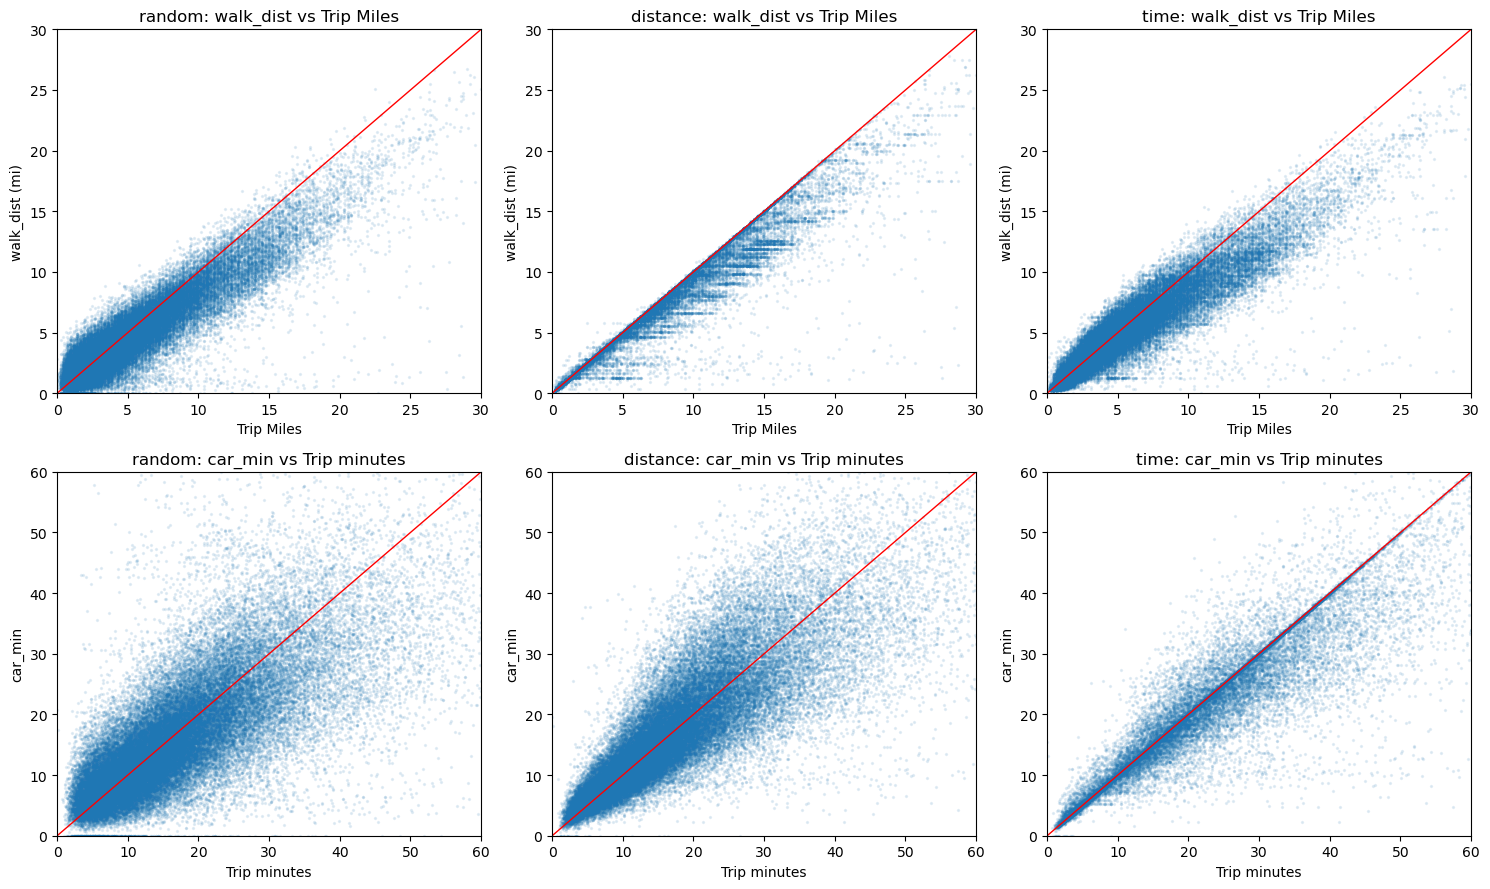

In [18]:
# ---- Evaluate all three methods: inferred OD vs the recorded trip ----------
# Each method is scored on BOTH a distance metric (inferred walk_dist vs Trip
# Miles) and a time metric (inferred congested car_min vs Trip Seconds / 60).
import matplotlib.pyplot as plt

methods = ['random', 'distance', 'time']

# (origin, destination) -> walk miles (Chicago pairs only)
dist_map = dist_lookup.to_dict()

def lookup_walk(pickup_col, dropoff_col):
    p, d = trips[pickup_col], trips[dropoff_col]
    out = pd.Series(
        [dist_map.get((int(a), int(b))) if (pd.notna(a) and pd.notna(b)) else np.nan
         for a, b in zip(p, d)], index=trips.index, dtype='float')
    out[(p == d) & out.isna()] = 0.0          # same-tract pairs -> 0 miles
    return out

def lookup_time(pickup_col, dropoff_col):
    # period-specific congested car time (minutes) for the inferred O-D pair
    tmp = pd.DataFrame({
        'origin_id':      trips[pickup_col].astype('Int64'),
        'destination_id': trips[dropoff_col].astype('Int64'),
        'time_period':    trips['time_period'].astype(str),
    }).merge(car_long, on=['origin_id', 'destination_id', 'time_period'], how='left')
    return pd.Series(tmp['car_min'].values, index=trips.index)

for m in methods:
    trips[f'walk_dist ({m})'] = lookup_walk(f'Inferred Pickup Census Tract ({m})',
                                            f'Inferred Dropoff Census Tract ({m})')
    trips[f'car_min ({m})']   = lookup_time(f'Inferred Pickup Census Tract ({m})',
                                            f'Inferred Dropoff Census Tract ({m})')

# Evaluate on the trips that actually needed inference.
mask = trips['Pickup Census Tract'].isna() | trips['Dropoff Census Tract'].isna()
sub = trips.loc[mask]
trip_min = sub['Trip Seconds'] / 60

def stats(pred, target):
    err = pred - target
    return err.abs().mean(), np.sqrt((err ** 2).mean()), pred.corr(target)

print("Distance metric: inferred walk_dist vs Trip Miles")
print(f"{'method':9s} {'MAE':>8s} {'RMSE':>8s} {'corr':>7s}")
for m in methods:
    mae, rmse, corr = stats(sub[f'walk_dist ({m})'], sub['Trip Miles'])
    print(f"{m:9s} {mae:8.3f} {rmse:8.3f} {corr:7.3f}")

print("\nTime metric: inferred congested car_min vs Trip Seconds / 60")
print(f"{'method':9s} {'MAE':>8s} {'RMSE':>8s} {'corr':>7s}")
for m in methods:
    mae, rmse, corr = stats(sub[f'car_min ({m})'], trip_min)
    print(f"{m:9s} {mae:8.3f} {rmse:8.3f} {corr:7.3f}")

# Scatter grid: rows = metric (distance, time), cols = method
fig, axes = plt.subplots(2, 3, figsize=(15, 9))
for j, m in enumerate(methods):
    s = sub.dropna(subset=[f'walk_dist ({m})'])
    axes[0, j].scatter(s['Trip Miles'], s[f'walk_dist ({m})'], s=2, alpha=0.1)
    axes[0, j].plot([0, 30], [0, 30], 'r-', lw=1)
    axes[0, j].set_xlim(0, 30); axes[0, j].set_ylim(0, 30)
    axes[0, j].set_title(f'{m}: walk_dist vs Trip Miles')
    axes[0, j].set_xlabel('Trip Miles'); axes[0, j].set_ylabel('walk_dist (mi)')

    s = sub.dropna(subset=[f'car_min ({m})'])
    axes[1, j].scatter(s['Trip Seconds'] / 60, s[f'car_min ({m})'], s=2, alpha=0.1)
    axes[1, j].plot([0, 60], [0, 60], 'r-', lw=1)
    axes[1, j].set_xlim(0, 60); axes[1, j].set_ylim(0, 60)
    axes[1, j].set_title(f'{m}: car_min vs Trip minutes')
    axes[1, j].set_xlabel('Trip minutes'); axes[1, j].set_ylabel('car_min')

plt.tight_layout()
plt.show()

In [19]:
# ---- Summary by pickup CA / dropoff CA, with names, % diffs, total row -----
obs_mask = trips['Pickup Census Tract'].notna() & trips['Dropoff Census Tract'].notna()

# community number -> name
ca_name = chi_tracts.drop_duplicates('community_num').set_index('community_num')['community']

def summarize(group_col):
    df = trips[[group_col, 'Trip Miles']].copy()
    df['observed'] = obs_mask.values
    g_all = df.groupby(group_col)
    g_obs = df[df['observed']].groupby(group_col)

    out = pd.DataFrame({
        'n_total':    g_all.size(),
        'n_observed': g_obs.size().reindex(g_all.size().index).fillna(0).astype(int),
        'miles_all':  g_all['Trip Miles'].mean(),
        'miles_obs':  g_obs['Trip Miles'].mean(),
    })
    out.insert(0, 'community', out.index.map(ca_name))
    out['pct_diff_n']     = (out['n_observed'] - out['n_total']) / out['n_total'] * 100
    out['pct_diff_miles'] = (out['miles_obs'] - out['miles_all']) / out['miles_all'] * 100
    out = out[['community', 'n_total', 'n_observed', 'pct_diff_n',
               'miles_all', 'miles_obs', 'pct_diff_miles']]

    # total row (overall, not a sum of per-CA means)
    n_tot, n_obs = len(df), int(df['observed'].sum())
    m_all, m_obs = df['Trip Miles'].mean(), df.loc[df['observed'], 'Trip Miles'].mean()
    out.loc['TOTAL'] = ['TOTAL', n_tot, n_obs, (n_obs - n_tot) / n_tot * 100,
                        m_all, m_obs, (m_obs - m_all) / m_all * 100]
    return out

for group_col in ['Pickup Community Area', 'Dropoff Community Area']:
    print(f"\n===== Grouped by {group_col} =====")
    print(summarize(group_col).round(2).to_string())



===== Grouped by Pickup Community Area =====
                                    community  n_total  n_observed  pct_diff_n  miles_all  miles_obs  pct_diff_miles
Pickup Community Area                                                                                               
1                                 ROGERS PARK     2219        1358      -38.80       6.59       7.05            6.90
2                                  WEST RIDGE     1780         848      -52.36       5.20       5.58            7.38
3                                      UPTOWN     3963        2959      -25.33       5.23       5.26            0.58
4                              LINCOLN SQUARE     1882        1052      -44.10       4.88       5.18            6.21
5                                NORTH CENTER     1938        1005      -48.14       4.73       4.75            0.42
6                                   LAKE VIEW     9078        6469      -28.74       4.69       4.58           -2.40
7                 

# Build the processed trips file

Write a processed trips file with all original columns plus the derived columns: time period; time-based inferred pickup/dropoff tracts; congested car time; calculated fare (non-shared regression); transit time (joined to the transit skims on the time-inferred tracts); walk time (from `Trip Miles` at 3 mph); and pickup/dropoff household income shares (ACS S1901).

In [20]:
# ---- Build the processed trips file ---------------------------------------
# Start from all original columns, then add the requested derived columns.
orig_cols = [
    'Trip ID', 'Trip Start Timestamp', 'Trip End Timestamp', 'Trip Seconds',
    'Trip Miles', 'Percent Time Chicago', 'Percent Distance Chicago',
    'Pickup Census Tract', 'Dropoff Census Tract', 'Pickup Community Area',
    'Dropoff Community Area', 'Fare', 'Tip', 'Additional Charges', 'Trip Total',
    'Shared Trip Authorized', 'Shared Trip Match', 'Trips Pooled',
    'Pickup Centroid Latitude', 'Pickup Centroid Longitude',
    'Pickup Centroid Location', 'Dropoff Centroid Latitude',
    'Dropoff Centroid Longitude', 'Dropoff Centroid Location',
]
processed = trips[orig_cols].copy()

# 1) time period
processed['time_period'] = trips['time_period']

# 2) time-based inferred pickup/dropoff census tracts
processed['Inferred Pickup Census Tract (time)']  = trips['Inferred Pickup Census Tract (time)']
processed['Inferred Dropoff Census Tract (time)'] = trips['Inferred Dropoff Census Tract (time)']

# 3) congested car time (minutes) for the time-inferred O-D in the trip's period
ct = pd.DataFrame({
    'origin_id':      trips['Inferred Pickup Census Tract (time)'].astype('Int64'),
    'destination_id': trips['Inferred Dropoff Census Tract (time)'].astype('Int64'),
    'time_period':    trips['time_period'].astype(str),
}).merge(car_long, on=['origin_id', 'destination_id', 'time_period'], how='left')
processed['congested_car_time_min'] = ct['car_min'].values

# 4) calculated fare from the non-shared (Shared Trip Authorized = False)
#    regression, applied to every trip
p = fare_models[False].params
processed['calc_fare'] = (
    p['const']
    + p['Trip Seconds'] * pd.to_numeric(processed['Trip Seconds'], errors='coerce')
    + p['Trip Miles']   * pd.to_numeric(processed['Trip Miles'],   errors='coerce'))

# 5) transit travel time, joined on the time-inferred tracts + time period
#    (same join as Make Estimation File.ipynb)
time_periods = ['night', 'am_peak', 'midday', 'pm_peak', 'evening']
transit_skim = pd.DataFrame()
for period in time_periods:
    skim = pd.read_csv(f'../mode_choice_estimation/data/transit_skim_{period}.csv')
    skim['time_period'] = period
    skim = skim.rename(columns={'from_id': 'o_tract_2020',
                                'to_id': 'd_tract_2020',
                                'travel_time_min': 'transit_time'})
    transit_skim = pd.concat([transit_skim, skim], ignore_index=True)
transit_skim['o_tract_2020'] = transit_skim['o_tract_2020'].astype('Int64')
transit_skim['d_tract_2020'] = transit_skim['d_tract_2020'].astype('Int64')

tt = pd.DataFrame({
    'o_tract_2020': trips['Inferred Pickup Census Tract (time)'].astype('Int64'),
    'd_tract_2020': trips['Inferred Dropoff Census Tract (time)'].astype('Int64'),
    'time_period':  trips['time_period'].astype(str),
}).merge(transit_skim, on=['o_tract_2020', 'd_tract_2020', 'time_period'], how='left')
processed['transit_time'] = tt['transit_time'].values

# 6) walk travel time (minutes) from Trip Miles, assuming 3 mph
processed['walk_time'] = pd.to_numeric(processed['Trip Miles'], errors='coerce') / 3 * 60

# 7) household income shares by tract (ACS S1901), joined for pickup & dropoff
#    using the time-inferred tracts (same calc as Make Estimation File.ipynb).
acs_hh = pd.read_csv('data/ACSST5Y2024.S1901-Data.csv', skiprows=1)

under_cols = ['Estimate!!Households!!Total!!Less than $10,000',
              'Estimate!!Households!!Total!!$10,000 to $14,999',
              'Estimate!!Households!!Total!!$15,000 to $24,999',
              'Estimate!!Households!!Total!!$25,000 to $34,999',
              'Estimate!!Households!!Total!!$35,000 to $49,999',
              'Estimate!!Households!!Total!!$50,000 to $74,999',
              'Estimate!!Households!!Total!!$75,000 to $99,999']
over_cols  = ['Estimate!!Households!!Total!!$100,000 to $149,999',
              'Estimate!!Households!!Total!!$150,000 to $199,999',
              'Estimate!!Households!!Total!!$200,000 or more']

acs_hh['hh_inc_under_100k'] = sum(pd.to_numeric(acs_hh[c], errors='coerce') for c in under_cols)
acs_hh['hh_inc_over_100k']  = sum(pd.to_numeric(acs_hh[c], errors='coerce') for c in over_cols)
denom = acs_hh['hh_inc_under_100k'] + acs_hh['hh_inc_over_100k']
acs_hh['hh_share_inc_under_100k'] = acs_hh['hh_inc_under_100k'] / denom
acs_hh['hh_share_inc_over_100k']  = acs_hh['hh_inc_over_100k']  / denom

# tract GEOID from the ACS Geography field ("1400000US17031010100" -> 17031010100)
acs_hh['tract_2020'] = pd.to_numeric(
    acs_hh['Geography'].str.split('US').str[1], errors='coerce').astype('Int64')
acs_shares = acs_hh[['tract_2020', 'hh_share_inc_under_100k', 'hh_share_inc_over_100k']]

for end, tract_col in [('Pickup',  'Inferred Pickup Census Tract (time)'),
                       ('Dropoff', 'Inferred Dropoff Census Tract (time)')]:
    m = pd.DataFrame({'tract_2020': trips[tract_col].astype('Int64')}).merge(
        acs_shares, on='tract_2020', how='left')
    processed[f'{end} hh_share_inc_under_100k'] = m['hh_share_inc_under_100k'].values
    processed[f'{end} hh_share_inc_over_100k']  = m['hh_share_inc_over_100k'].values

# write out
processed.to_csv('out/processed_tnp_trips.csv', index=False)
print(f"Wrote {len(processed):,} rows x {processed.shape[1]} columns "
      f"out/processed_tnp_trips.csv")
processed.head()

Wrote 182,752 rows x 35 columns out/processed_tnp_trips.csv


,Trip ID,Trip Start Timestamp,Trip End Timestamp,Trip Seconds,Trip Miles,Percent Time Chicago,Percent Distance Chicago,Pickup Census Tract,Dropoff Census Tract,Pickup Community Area,Dropoff Community Area,Fare,Tip,Additional Charges,Trip Total,Shared Trip Authorized,Shared Trip Match,Trips Pooled,Pickup Centroid Latitude,Pickup Centroid Longitude,Pickup Centroid Location,Dropoff Centroid Latitude,Dropoff Centroid Longitude,Dropoff Centroid Location,time_period,Inferred Pickup Census Tract (time),Inferred Dropoff Census Tract (time),congested_car_time_min,calc_fare,transit_time,walk_time,Pickup hh_share_inc_under_100k,Pickup hh_share_inc_over_100k,Dropoff hh_share_inc_under_100k,Dropoff hh_share_inc_over_100k
1,f5045620992c5bb5cac200d5db51fbc9d1e980dc,04/16/2025 11:45:00 PM,04/17/2025 12:00:00 AM,396,1.0,99%,98%,17031081600,17031320100,8,32,$7.5,$0,$3.41,$10.91,False,False,1,41.892073,-87.628874,POINT (-87.6288741572 41.8920726347),41.884987,-87.620993,POINT (-87.6209929134 41.8849871918),night,17031081600,17031320100,NaN,7.075723,NaN,20.0,0.319000,0.681000,NaN,NaN
2,f5189089ccfbbde63cc147ad6c15a35b7d3acb89,04/16/2025 11:45:00 PM,04/16/2025 11:45:00 PM,737,2.9,100%,100%,17031060400,17031030500,6,77,$5,$3,$3.13,$11.13,False,False,1,41.950673,-87.666536,POINT (-87.6665362813 41.9506733576),41.987226,-87.664938,POINT (-87.6649377243 41.9872255578),night,17031060400,17031030500,8.266137,11.255542,75.0,58.0,0.267000,0.733000,0.348303,0.651697
3,f53b28d0530f1e3657d0741e2cf98574a3683b75,04/16/2025 11:45:00 PM,04/17/2025 12:00:00 AM,310,1.5,100%,100%,<NA>,<NA>,41,39,$7.5,$0,$2.31,$9.81,False,False,1,41.794090,-87.592311,POINT (-87.592310855 41.794090253),41.808916,-87.596183,POINT (-87.5961833442 41.8089162826),night,17031411100,17031390500,5.166087,6.908713,40.0,30.0,0.426573,0.573427,0.594595,0.405405
4,f55bc6fbaee328d0ee6108316cb12daf270099b9,04/16/2025 11:45:00 PM,04/17/2025 12:15:00 AM,1243,8.8,100%,100%,<NA>,<NA>,4,33,$12.5,$0,$3.33,$15.83,False,False,1,41.975171,-87.687516,POINT (-87.6875155152 41.9751709433),41.857184,-87.620335,POINT (-87.6203346241 41.8571838585),night,17031040100,17031330200,20.717935,20.248924,999.0,176.0,0.551000,0.449000,0.304695,0.695305
5,f56a5b36e42c9067ddf4ac0a40a9fb568034eb30,04/16/2025 11:45:00 PM,04/17/2025 12:00:00 AM,314,1.5,100%,100%,<NA>,<NA>,31,28,$7.5,$0,$1.23,$8.73,False,False,1,41.850266,-87.667569,POINT (-87.667569312 41.8502663663),41.874005,-87.663518,POINT (-87.6635175498 41.874005383),night,17031843200,17031832900,5.243489,6.937551,49.0,30.0,0.567000,0.433000,0.585000,0.415000
